# Training Q-Learning Rute Lari Loop 5 KM

Notebook ini menjalankan Q-Learning pada graf OpenStreetMap dan `comfort_score` edge yang telah dibangun pada `analisa.ipynb`.

Urutan eksekusi adalah A, B, C, lalu D. Setiap scenario menjalankan training untuk lima seed, menampilkan metrik dan grafik training, kemudian menampilkan peta interaktif rute representatif sebelum melanjutkan ke scenario berikutnya.

In [9]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


## 1. Memuat Graf dan Konfigurasi Eksperimen

Graf dimuat dari file GraphML hasil analisis. Skor comfort dibangun ulang agar notebook training dapat dijalankan mandiri tanpa bergantung pada variabel di `analisa.ipynb`.

Eksperimen menargetkan loop 5 km dengan jarak valid 4,5–5,5 km. Keempat scenario memakai environment yang sama: action Q-table adalah `(next_node, key)`, revisit hanya menjadi fallback setelah 70% target jarak, dan setiap node dapat dikunjungi paling banyak dua kali. Perbedaan antar scenario hanya terletak pada informasi state.

In [17]:
from __future__ import annotations

import ast
import re
import time
from collections import defaultdict
from pathlib import Path
from typing import Any

import folium
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from IPython.display import display
from pyproj import Transformer

# ------------------------------------------------------------
# LOKASI DAN FILE GRAF
# ------------------------------------------------------------
START_LAT = -7.282187
START_LON = 112.709282

DATA_DIR = Path("data_osm_5km")
GRAPH_PATH = DATA_DIR / "graf_jalan_kaki_5km.graphml"
RESULT_DIR = Path("hasil_bab_4") / "training_qlearning_5km"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

if not GRAPH_PATH.exists():
    raise FileNotFoundError(
        f"File graf tidak ditemukan: {GRAPH_PATH}. Jalankan analisa.ipynb lebih dahulu."
    )

# GraphML yang disimpan dari analisa.ipynb sudah diproyeksikan ke meter.
G = ox.io.load_graphml(GRAPH_PATH)

# Transformasi titik start dari latitude-longitude ke CRS graf,
# lalu cari node graf yang paling dekat.
TO_PROJECTED = Transformer.from_crs("EPSG:4326", G.graph["crs"], always_xy=True)
start_x, start_y = TO_PROJECTED.transform(START_LON, START_LAT)
START_NODE = int(ox.distance.nearest_nodes(G, X=start_x, Y=start_y))

# ------------------------------------------------------------
# KONFIGURASI RUTE DAN Q-LEARNING
# ------------------------------------------------------------
TARGET_DISTANCE_M = 5_000
DISTANCE_TOLERANCE = 0.10
MIN_DISTANCE_M = TARGET_DISTANCE_M * (1 - DISTANCE_TOLERANCE)
MAX_DISTANCE_M = TARGET_DISTANCE_M * (1 + DISTANCE_TOLERANCE)

# Semua scenario memakai environment dan aturan revisit yang sama.
ALLOW_REVISIT = True
REVISIT_AFTER_RATIO = 0.70
MAX_NODE_VISITS = 2
PROGRESS_BINS = 16
REVISIT_COUNT_BINS = 3

# Parameter reward yang telah disepakati.
NEUTRAL_COMFORT_SCORE = 0.50
RETURN_PHASE_RATIO = 0.55
RETURN_REWARD_SCALE = 0.40
SUCCESS_BONUS = 80.0
OVER_DISTANCE_PENALTY = -50.0
NO_ACTION_PENALTY = -45.0
EARLY_RETURN_PENALTY = -45.0
STEP_LIMIT_PENALTY = -40.0
REVISIT_PENALTY = -8.0

# Hyperparameter Q-Learning.
ALPHA = 0.15
GAMMA = 0.95
EPSILON_START = 1.00
EPSILON_END = 0.05
EPISODES = 2_500
MAX_STEPS_PER_EPISODE = 220
SEEDS = (0, 1, 2, 3, 4)
ROLLING_WINDOW = 100

print(f"Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge")
print(f"CRS graf: {G.graph['crs']}")
print(f"Node start: {START_NODE}")
print(f"Target loop: {MIN_DISTANCE_M/1000:.1f}–{MAX_DISTANCE_M/1000:.1f} km")
print(f"Training: 4 scenario × {len(SEEDS)} seed × {EPISODES:,} episode")


Graf: 8,027 node, 21,374 edge
CRS graf: EPSG:32749
Node start: 1720975931
Target loop: 4.5–5.5 km
Training: 4 scenario × 5 seed × 2,500 episode


## 2. Core Q-Learning

Bagian ini membangun skor comfort edge, action `(next_node, key)`, state A–D, environment rute, Q-table, epsilon-greedy, training history, grafik training, dan peta interaktif. State dibentuk melalui fungsi `build_state()`.

In [18]:
# ============================================================
# A. MEMBANGUN COMFORT SCORE PADA EDGE
# ============================================================

HIGHWAY_SCORES = {
    "footway": 0.95, "pedestrian": 0.95, "path": 0.85,
    "living_street": 0.80, "residential": 0.75, "service": 0.60,
    "unclassified": 0.55, "tertiary": 0.45, "tertiary_link": 0.45,
    "secondary": 0.35, "secondary_link": 0.35, "track": 0.35,
    "primary": 0.20, "primary_link": 0.20, "trunk": 0.10,
    "trunk_link": 0.10, "steps": 0.10,
}
SURFACE_SCORES = {
    "asphalt": 1.00, "concrete": 0.90, "paved": 0.90,
    "paving_stones": 0.75, "sett": 0.65, "compacted": 0.55,
    "fine_gravel": 0.45, "gravel": 0.30, "dirt": 0.25,
    "ground": 0.20, "unpaved": 0.20,
}
HIGHWAY_NEUTRAL_SCORE = 0.50
SURFACE_NEUTRAL_SCORE = 0.50
WIDTH_NEUTRAL_SCORE = 0.50
WIDTH_MIN_M, WIDTH_MAX_M = 1.0, 5.0
WIDTH_MIN_SCORE, WIDTH_MAX_SCORE = 0.25, 1.00
WEIGHT_HIGHWAY, WEIGHT_SURFACE, WEIGHT_WIDTH = 0.55, 0.30, 0.15

def is_missing(value: Any) -> bool:
    """Mendeteksi nilai OSM yang kosong tanpa gagal pada list hasil simplify."""
    return value is None or value is pd.NA or (isinstance(value, float) and np.isnan(value))

def osm_values(value: Any) -> list[str]:
    """Mengubah string/list GraphML menjadi list tag OSM huruf kecil."""
    if is_missing(value):
        return []
    if isinstance(value, str):
        text = value.strip()
        # GraphML kadang memuat list OSM sebagai teks seperti "['asphalt', 'concrete']".
        if text.startswith("[") and text.endswith("]"):
            try:
                parsed = ast.literal_eval(text)
                if isinstance(parsed, (list, tuple, set)):
                    return [str(item).strip().lower() for item in parsed]
            except (ValueError, SyntaxError):
                pass
        return [text.lower()]
    if isinstance(value, (list, tuple, set)):
        return [str(item).strip().lower() for item in value]
    return [str(value).strip().lower()]

def parse_width_m(value: Any) -> float | None:
    """Membaca width tunggal dalam meter; list/multiple values dikembalikan None."""
    if is_missing(value) or isinstance(value, (list, tuple, set)):
        return None
    text = str(value).strip().lower().replace(",", ".")
    if text.startswith("[") or ";" in text:
        return None
    match = re.fullmatch(r"(\d+(?:\.\d+)?)\s*(?:m|meter|metre|meters|metres)?", text)
    if match is None:
        return None
    width_m = float(match.group(1))
    return width_m if width_m > 0 else None

def conservative_score(value: Any, score_map: dict[str, float], neutral: float) -> float:
    """Untuk edge gabungan, gunakan skor terendah karena semua bagian harus dilalui."""
    values = osm_values(value)
    if not values:
        return neutral
    return min(score_map.get(item, neutral) for item in values)

def width_score(value: Any) -> float:
    """Normalisasi width 1–5 m menjadi skor 0,25–1,00; data kosong bernilai netral."""
    width_m = parse_width_m(value)
    if width_m is None:
        return WIDTH_NEUTRAL_SCORE
    proportion = np.clip((width_m - WIDTH_MIN_M) / (WIDTH_MAX_M - WIDTH_MIN_M), 0.0, 1.0)
    return float(WIDTH_MIN_SCORE + proportion * (WIDTH_MAX_SCORE - WIDTH_MIN_SCORE))

def add_comfort_scores(graph: nx.MultiDiGraph) -> None:
    """Menambahkan skor komponen dan comfort_score ke setiap edge graf."""
    for _, _, _, data in graph.edges(keys=True, data=True):
        h_score = conservative_score(data.get("highway"), HIGHWAY_SCORES, HIGHWAY_NEUTRAL_SCORE)
        s_score = conservative_score(data.get("surface"), SURFACE_SCORES, SURFACE_NEUTRAL_SCORE)
        w_score = width_score(data.get("width"))
        comfort = WEIGHT_HIGHWAY * h_score + WEIGHT_SURFACE * s_score + WEIGHT_WIDTH * w_score
        data["highway_score"] = float(h_score)
        data["surface_score"] = float(s_score)
        data["width_score"] = float(w_score)
        data["comfort_score"] = float(np.clip(comfort, 0.0, 1.0))

add_comfort_scores(G)
NODE_XY = {int(node): (float(data["x"]), float(data["y"])) for node, data in G.nodes(data=True)}

# ============================================================
# B. ACTION EDGE DAN PEMBENTUKAN STATE
# ============================================================

class EdgeAction:
    """Satu action adalah edge spesifik menuju node tujuan dengan key tertentu."""

    def __init__(self, next_node: int, key: Any, length_m: float, comfort_score: float, data: dict):
        # Menyimpan informasi edge yang dipilih agen.
        self.next_node = next_node
        self.key = key
        self.length_m = length_m
        self.comfort_score = comfort_score
        self.data = data

    def get_action_id(self) -> tuple[int, Any]:
        # current_node sudah ada di state, sehingga action Q-table cukup (v, key).
        return (self.next_node, self.key)

def build_actions(graph: nx.MultiDiGraph) -> dict[int, list[EdgeAction]]:
    """Membuat daftar seluruh edge keluar dari setiap node tanpa menghapus edge paralel."""
    actions_by_node: dict[int, list[EdgeAction]] = defaultdict(list)
    for u, v, key, data in graph.edges(keys=True, data=True):
        length_m = float(data.get("length", 0.0))
        if length_m <= 0:
            continue
        actions_by_node[int(u)].append(
            EdgeAction(int(v), key, length_m, float(data["comfort_score"]), data)
        )
    for node in actions_by_node:
        actions_by_node[node].sort(key=lambda action: (action.next_node, str(action.key)))
    return actions_by_node

ACTIONS_BY_NODE = build_actions(G)

def build_state(env: "RunningRouteEnvironment", scenario: str) -> tuple:
    """Membentuk state A–D dari kondisi environment saat ini."""
    if scenario == "A":
        return (env.current_node,)
    if scenario == "B":
        return (env.current_node, env.progress_bin())
    if scenario == "C":
        return (env.current_node, env.previous_node, env.progress_bin())
    if scenario == "D":
        return (
            env.current_node,
            env.previous_node,
            env.progress_bin(),
            env.revisit_count_bin(),
        )
    raise ValueError(f"Scenario tidak dikenal: {scenario}")

# ============================================================
# C. ENVIRONMENT RUTE LARI FROM SCRATCH
# ============================================================

class RunningRouteEnvironment:
    """Environment untuk pembentukan rute loop 5 km."""

    def __init__(self, start_node: int, scenario: str):
        self.start_node = int(start_node)
        self.scenario = scenario
        self.reset()

    def reset(self) -> tuple:
        """Memulai satu episode baru dari node start."""
        self.current_node = self.start_node
        self.previous_node = -1
        self.total_distance_m = 0.0
        self.step_count = 0
        self.node_visits = defaultdict(int, {self.start_node: 1})
        self.revisit_count = 0
        self.path_nodes = [self.start_node]
        self.path_actions: list[tuple[int, EdgeAction]] = []
        self.done = False
        self.is_loop = False
        self.termination_reason = "running"
        return build_state(self, self.scenario)

    def progress_bin(self) -> int:
        """Mengubah jarak kontinu menjadi 16 kategori progres untuk state B–D."""
        raw_bin = int(self.total_distance_m / MAX_DISTANCE_M * PROGRESS_BINS)
        return min(PROGRESS_BINS - 1, max(0, raw_bin))

    def revisit_count_bin(self) -> int:
        """Membatasi jumlah kategori revisit agar Q-table tetap kecil."""
        return min(REVISIT_COUNT_BINS - 1, self.revisit_count)

    def straight_distance_to_start(self, node: int) -> float:
        """Jarak Euclidean/Pythagoras dalam meter dari node ke titik start."""
        x, y = NODE_XY[node]
        x0, y0 = NODE_XY[self.start_node]
        return float(np.hypot(x - x0, y - y0))

    def available_actions(self) -> list[EdgeAction]:
        """Menghasilkan action legal dengan aturan fresh node, closing, dan revisit fallback."""
        fresh_actions, closing_actions, revisit_actions = [], [], []
        for action in ACTIONS_BY_NODE.get(self.current_node, []):
            next_node = action.next_node
            next_distance = self.total_distance_m + action.length_m

            # Kembali ke start hanya legal jika langsung membentuk loop pada jarak valid.
            if next_node == self.start_node:
                if self.current_node != self.start_node and MIN_DISTANCE_M <= next_distance <= MAX_DISTANCE_M:
                    closing_actions.append(action)
                continue

            # Node baru selalu diprioritaskan untuk menjaga rute tidak berulang.
            if self.node_visits[next_node] == 0:
                fresh_actions.append(action)
                continue

            # Semua scenario memakai aturan revisit sama: hanya fallback setelah 70% target.
            if (
                ALLOW_REVISIT
                and self.total_distance_m >= REVISIT_AFTER_RATIO * TARGET_DISTANCE_M
                and self.node_visits[next_node] < MAX_NODE_VISITS
            ):
                revisit_actions.append(action)

        if fresh_actions:
            return fresh_actions + closing_actions
        if ALLOW_REVISIT:
            return revisit_actions + closing_actions
        return closing_actions

    def stop_without_action(self) -> tuple[tuple, float, bool, dict]:
        """Mengakhiri episode ketika action mask tidak menyisakan action legal."""
        self.done = True
        self.termination_reason = "no_available_action"
        info = self.info()
        return build_state(self, self.scenario), NO_ACTION_PENALTY, True, info

    def step(self, action: EdgeAction) -> tuple[tuple, float, bool, dict]:
        """Menerapkan satu action edge, memperbarui environment, dan menghitung reward."""
        if self.done:
            raise RuntimeError("Episode selesai. Panggil reset() sebelum step().")

        # Validasi action menjaga agar policy tidak dapat melewati action mask.
        legal_action_ids = {candidate.get_action_id() for candidate in self.available_actions()}
        if action.get_action_id() not in legal_action_ids:
            raise ValueError("Action tidak legal untuk state environment saat ini.")

        current_node = self.current_node
        next_node = action.next_node
        distance_before = self.straight_distance_to_start(current_node)
        is_revisit = self.node_visits[next_node] > 0

        # Perbarui posisi, jarak, riwayat, dan jumlah kunjungan.
        self.total_distance_m += action.length_m
        self.previous_node = current_node
        self.current_node = next_node
        self.path_nodes.append(next_node)
        self.path_actions.append((current_node, action))
        self.node_visits[next_node] += 1
        self.step_count += 1

        # Reward comfort proporsional panjang edge, dengan 0,50 sebagai nilai netral.
        reward = (action.comfort_score - NEUTRAL_COMFORT_SCORE) * (action.length_m / 100.0)

        # Penalti revisit berlaku pada semua scenario bila revisit benar-benar terjadi.
        if is_revisit and next_node != self.start_node:
            self.revisit_count += 1
            reward += REVISIT_PENALTY

        # Cek kondisi terminal. is_loop hanya berarti kembali ke start pada rentang valid.
        if next_node == self.start_node and MIN_DISTANCE_M <= self.total_distance_m <= MAX_DISTANCE_M:
            self.done = True
            self.is_loop = True
            self.termination_reason = "success"
            reward += SUCCESS_BONUS
        elif next_node == self.start_node:
            self.done = True
            self.termination_reason = "early_return"
            reward += EARLY_RETURN_PENALTY
        elif self.total_distance_m > MAX_DISTANCE_M:
            self.done = True
            self.termination_reason = "over_distance"
            reward += OVER_DISTANCE_PENALTY
        elif self.step_count >= MAX_STEPS_PER_EPISODE:
            self.done = True
            self.termination_reason = "step_limit"
            reward += STEP_LIMIT_PENALTY
        elif self.total_distance_m >= RETURN_PHASE_RATIO * TARGET_DISTANCE_M:
            # Setelah 55% target, agen mendapat sinyal positif bila mendekati start.
            distance_after = self.straight_distance_to_start(next_node)
            reward += RETURN_REWARD_SCALE * (distance_before - distance_after) / 100.0

        info = self.info()
        info["is_revisit"] = is_revisit
        info["edge_comfort"] = action.comfort_score
        info["edge_length_m"] = action.length_m
        return build_state(self, self.scenario), float(reward), self.done, info

    def info(self) -> dict:
        """Informasi tambahan untuk training history dan evaluasi."""
        return {
            "is_loop": self.is_loop,
            "termination_reason": self.termination_reason,
            "total_distance_m": self.total_distance_m,
            "step_count": self.step_count,
            "revisit_count": self.revisit_count,
        }

# ============================================================
# D. POLICY, Q-LEARNING, DAN METRIK
# ============================================================

def choose_action(q_table, state: tuple, actions: list[EdgeAction], rng, epsilon: float) -> EdgeAction:
    """Memilih action dengan epsilon-greedy dari action yang telah lolos action mask."""
    if rng.random() < epsilon:
        return actions[int(rng.integers(len(actions)))]
    values = np.array([q_table[state].get(action.get_action_id(), 0.0) for action in actions])
    best_indices = np.flatnonzero(np.isclose(values, values.max()))
    return actions[int(rng.choice(best_indices))]

def route_metrics(env: RunningRouteEnvironment, total_reward: float) -> dict:
    """Mengubah satu rute selesai menjadi metrik evaluasi yang konsisten."""
    edge_length = sum(action.length_m for _, action in env.path_actions)
    mean_comfort = (
        sum(action.comfort_score * action.length_m for _, action in env.path_actions) / edge_length
        if edge_length else np.nan
    )
    unique_edges = len({(u, action.next_node, action.key) for u, action in env.path_actions})
    intermediate = env.path_nodes[1:-1]
    return {
        "is_loop": env.is_loop,
        "termination_reason": env.termination_reason,
        "distance_m": env.total_distance_m,
        "distance_km": env.total_distance_m / 1000.0,
        "absolute_distance_error_m": abs(env.total_distance_m - TARGET_DISTANCE_M),
        "steps": env.step_count,
        "total_reward": total_reward,
        "mean_comfort": mean_comfort,
        "revisit_count": env.revisit_count,
        "repeated_intermediate_nodes": len(intermediate) - len(set(intermediate)),
        "unique_edge_ratio": unique_edges / len(env.path_actions) if env.path_actions else 0.0,
    }

def train_q_learning(scenario: str, seed: int):
    """Melatih satu Q-table dan menyimpan satu baris history untuk setiap episode."""
    env = RunningRouteEnvironment(START_NODE, scenario)
    rng = np.random.default_rng(seed)
    q_table = defaultdict(dict)
    history_rows = []
    started = time.perf_counter()

    for episode in range(EPISODES):
        state = env.reset()
        epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * (1 - episode / max(1, EPISODES - 1))
        episode_reward = 0.0

        for _ in range(MAX_STEPS_PER_EPISODE):
            actions = env.available_actions()
            if not actions:
                next_state, stop_reward, done, _ = env.stop_without_action()
                episode_reward += stop_reward
                reward = stop_reward
                next_actions = []
            else:
                action = choose_action(q_table, state, actions, rng, epsilon)
                next_state, reward, done, _ = env.step(action)
                episode_reward += reward
                next_actions = [] if done else env.available_actions()

                # Jika state baru tidak memiliki action legal, masukkan penalti ke transisi ini.
                if not done and not next_actions:
                    _, stop_reward, done, _ = env.stop_without_action()
                    reward += stop_reward
                    episode_reward += stop_reward

                # Update Q(s,a) hanya dilakukan jika agen benar-benar memilih action.
                future_value = max(
                    (q_table[next_state].get(next_action.get_action_id(), 0.0) for next_action in next_actions),
                    default=0.0,
                )
                old_value = q_table[state].get(action.get_action_id(), 0.0)
                q_table[state][action.get_action_id()] = old_value + ALPHA * (
                    reward + GAMMA * future_value - old_value
                )

            state = next_state
            if done:
                break

        # Jika loop for selesai normal, environment belum dihentikan oleh step_limit.
        if not env.done:
            env.done = True
            env.termination_reason = "step_limit"
            episode_reward += STEP_LIMIT_PENALTY

        metrics = route_metrics(env, episode_reward)
        metrics.update({
            "scenario": scenario,
            "seed": seed,
            "episode": episode + 1,
            "epsilon": epsilon,
            "q_state_count": len(q_table),
        })
        history_rows.append(metrics)

    return q_table, pd.DataFrame(history_rows), time.perf_counter() - started

def evaluate_greedy(scenario: str, q_table, seed: int):
    """Mengevaluasi policy hasil training tanpa eksplorasi (epsilon=0)."""
    env = RunningRouteEnvironment(START_NODE, scenario)
    rng = np.random.default_rng(seed + 100_000)
    state = env.reset()
    total_reward = 0.0

    for _ in range(MAX_STEPS_PER_EPISODE):
        actions = env.available_actions()
        if not actions:
            _, reward, _, _ = env.stop_without_action()
            total_reward += reward
            break
        action = choose_action(q_table, state, actions, rng, epsilon=0.0)
        state, reward, done, _ = env.step(action)
        total_reward += reward
        if done:
            break
    else:
        env.done = True
        env.termination_reason = "step_limit"
        total_reward += STEP_LIMIT_PENALTY

    return env, route_metrics(env, total_reward)

def run_scenario(scenario: str):
    """Menjalankan training dan evaluasi greedy untuk lima seed pada satu scenario state."""
    histories, evaluation_rows, trials = [], [], []
    print(f"\\nMenjalankan scenario {scenario} ...")
    for seed in SEEDS:
        q_table, history, training_seconds = train_q_learning(scenario, seed)
        env, metrics = evaluate_greedy(scenario, q_table, seed)
        metrics.update({"scenario": scenario, "seed": seed, "q_state_count": len(q_table), "training_seconds": training_seconds})
        histories.append(history)
        evaluation_rows.append(metrics)
        trials.append({"env": env, "metrics": metrics, "q_table": q_table})
        print(f"  seed={seed}: {metrics['termination_reason']}, {metrics['distance_km']:.2f} km, is_loop={metrics['is_loop']}")
    return pd.concat(histories, ignore_index=True), pd.DataFrame(evaluation_rows), trials

# ============================================================
# E. GRAFIK TRAINING DAN PETA INTERAKTIF PER SCENARIO
# ============================================================

def plot_training_charts(history_df: pd.DataFrame, scenario: str):
    """Menampilkan rata-rata 100 episode terakhir, pertumbuhan Q-table, dan jadwal epsilon."""
    mean_history = history_df.groupby("episode", as_index=False).agg(
        success_rate=("is_loop", "mean"), mean_reward=("total_reward", "mean"),
        mean_distance_km=("distance_km", "mean"), mean_comfort=("mean_comfort", "mean"),
        mean_q_state_count=("q_state_count", "mean"),
        mean_epsilon=("epsilon", "mean"),
    )
    rolling = mean_history.set_index("episode").rolling(ROLLING_WINDOW, min_periods=1).mean().reset_index()

    fig, axes = plt.subplots(3, 2, figsize=(14, 13))
    fig.suptitle(f"Training Q-Learning Scenario {scenario} — rolling {ROLLING_WINDOW} episode", fontsize=14, fontweight="bold")

    axes[0, 0].plot(rolling["episode"], rolling["success_rate"], color="#16A34A")
    axes[0, 0].set(title="Rata-rata Keberhasilan 100 Episode Terakhir", xlabel="Episode", ylabel="Proporsi is_loop", ylim=(-0.02, 1.02))

    axes[0, 1].plot(rolling["episode"], rolling["mean_reward"], color="#2563EB")
    axes[0, 1].set(title="Rata-rata Reward 100 Episode Terakhir", xlabel="Episode", ylabel="Reward")

    axes[1, 0].plot(rolling["episode"], rolling["mean_distance_km"], color="#7C3AED")
    axes[1, 0].axhline(TARGET_DISTANCE_M / 1000, color="black", linestyle="--", label="Target 5 km")
    axes[1, 0].axhline(MIN_DISTANCE_M / 1000, color="#9CA3AF", linestyle=":", label="Batas valid")
    axes[1, 0].axhline(MAX_DISTANCE_M / 1000, color="#9CA3AF", linestyle=":")
    axes[1, 0].set(title="Rata-rata Jarak 100 Episode Terakhir", xlabel="Episode", ylabel="Jarak (km)")
    axes[1, 0].legend()

    axes[1, 1].plot(rolling["episode"], rolling["mean_comfort"], color="#F59E0B")
    axes[1, 1].set(title="Rata-rata Skor Kenyamanan 100 Episode Terakhir", xlabel="Episode", ylabel="Comfort score", ylim=(0, 1))

    axes[2, 0].plot(rolling["episode"], rolling["mean_q_state_count"], color="#DC2626")
    axes[2, 0].set(title="Jumlah State Q-table", xlabel="Episode", ylabel="Jumlah state")

    # Epsilon adalah jadwal eksplorasi, bukan metrik hasil episode.
    # Karena semua seed memakai schedule yang sama, tampilkan nilai rata-rata
    # langsung per episode agar penurunannya terlihat apa adanya.
    axes[2, 1].plot(mean_history["episode"], mean_history["mean_epsilon"], color="#0891B2")
    axes[2, 1].set(title="Jadwal Epsilon", xlabel="Episode", ylabel="Epsilon", ylim=(0, 1.05))
    for axis in axes.flat:
        axis.grid(alpha=0.25)
    plt.tight_layout()
    chart_path = RESULT_DIR / f"grafik_training_{scenario}.png"
    fig.savefig(chart_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Grafik training tersimpan: {chart_path}")

TO_WGS84 = Transformer.from_crs(G.graph["crs"], "EPSG:4326", always_xy=True)
FROM_WGS84 = Transformer.from_crs("EPSG:4326", G.graph["crs"], always_xy=True)
KM_COLORS = ["#2457F5", "#00A884", "#F59E0B", "#8B3DFF", "#EF4444"]

def node_latlon(node: int) -> tuple[float, float]:
    """Mengubah node x-y meter menjadi (latitude, longitude) untuk Folium."""
    lon, lat = TO_WGS84.transform(*NODE_XY[node])
    return lat, lon

def offset_latlon(latlon: tuple[float, float], dx_m=12, dy_m=12) -> tuple[float, float]:
    """Menggeser simbol finish pada peta tanpa mengubah posisi finish sebenarnya."""
    lat, lon = latlon
    x, y = FROM_WGS84.transform(lon, lat)
    new_lon, new_lat = TO_WGS84.transform(x + dx_m, y + dy_m)
    return new_lat, new_lon

def edge_latlon(current_node: int, action: EdgeAction) -> list[tuple[float, float]]:
    """Mengambil geometri edge dalam koordinat Folium dan memastikan arah u -> v benar."""
    geometry = action.data.get("geometry")
    coords = list(geometry.coords) if hasattr(geometry, "coords") else [NODE_XY[current_node], NODE_XY[action.next_node]]
    x0, y0 = NODE_XY[current_node]
    if np.hypot(coords[-1][0] - x0, coords[-1][1] - y0) < np.hypot(coords[0][0] - x0, coords[0][1] - y0):
        coords.reverse()
    return [(lat, lon) for lon, lat in (TO_WGS84.transform(x, y) for x, y in coords)]

def km_marker(number: int, color: str):
    """Marker bulat sederhana seperti marker navigasi per kilometer."""
    html = f'<div style="width:26px;height:26px;line-height:26px;text-align:center;border-radius:50%;background:{color};color:#fff;border:2px solid #fff;font:700 12px Arial,sans-serif;box-shadow:0 1px 4px rgba(0,0,0,.4)">{number}</div>'
    return folium.DivIcon(html=html, icon_size=(26, 26), icon_anchor=(13, 13), class_name="route-km-number")

def route_milestones(env: RunningRouteEnvironment) -> dict[int, tuple[float, float]]:
    """Mengambil lokasi node pertama setelah rute melampaui KM 1 sampai KM 5."""
    result, cumulative_m, km = {}, 0.0, 1
    for current_node, action in env.path_actions:
        next_total = cumulative_m + action.length_m
        while km <= 5 and next_total >= km * 1000:
            result[km] = edge_latlon(current_node, action)[-1]
            km += 1
        cumulative_m = next_total
    return result

def make_route_map(trial: dict, scenario: str):
    """Membuat peta rute representatif dengan warna berbeda per kilometer."""
    env, metrics = trial["env"], trial["metrics"]
    start = node_latlon(env.start_node)
    route_map = folium.Map(location=start, zoom_start=15, tiles="OpenStreetMap", control_scale=True)

    cumulative_m = 0.0
    for current_node, action in env.path_actions:
        color_index = min(4, int(cumulative_m // 1000))
        folium.PolyLine(edge_latlon(current_node, action), color=KM_COLORS[color_index], weight=6, opacity=0.92, tooltip=f"Segmen KM {color_index}–{color_index + 1}").add_to(route_map)
        cumulative_m += action.length_m

    folium.Marker(start, tooltip="START — KM 0", popup="<b>START</b><br>KM 0", icon=folium.Icon(color="green", icon="play", prefix="fa")).add_to(route_map)
    for km, location in route_milestones(env).items():
        if not (km == 5 and metrics["is_loop"]):
            folium.Marker(location, tooltip=f"KM {km}", icon=km_marker(km, KM_COLORS[km - 1])).add_to(route_map)

    if metrics["is_loop"]:
        finish_location = offset_latlon(start)
        finish_popup = "<b>FINISH</b><br>KM 5 — kembali ke titik start"
        finish_tooltip = "FINISH — KM 5 (posisi asli sama dengan start)"
        finish_color = "purple"
    else:
        finish_location = node_latlon(env.path_nodes[-1])
        finish_popup = f"<b>FINISH</b><br>{metrics['distance_km']:.2f} km"
        finish_tooltip = "FINISH — rute belum kembali ke start"
        finish_color = "red"
    folium.Marker(finish_location, tooltip=finish_tooltip, popup=finish_popup, icon=folium.Icon(color=finish_color, icon="flag-checkered", prefix="fa")).add_to(route_map)

    legend = ''.join(f'<span style="display:inline-block;margin-right:8px"><i style="display:inline-block;width:18px;height:5px;vertical-align:middle;background:{color};margin-right:3px"></i>{i}–{i + 1} km</span>' for i, color in enumerate(KM_COLORS))
    info = f'<b>Scenario {scenario} — seed {metrics["seed"]}</b><br>is_loop: {metrics["is_loop"]}<br>Jarak: {metrics["distance_km"]:.2f} km<br>Comfort: {metrics["mean_comfort"]:.3f}<br>Revisit: {metrics["revisit_count"]}<hr style="margin:4px 0">{legend}'
    route_map.get_root().html.add_child(folium.Element(f'<div style="position:fixed;left:12px;bottom:12px;z-index:9999;background:rgba(255,255,255,.94);border:1px solid #aaa;border-radius:6px;padding:8px;font:12px Arial,sans-serif">{info}</div>'))
    return route_map

def present_scenario(history_df: pd.DataFrame, metrics_df: pd.DataFrame, trials: list[dict], scenario: str):
    """Menyimpan hasil, menampilkan tabel/grafik, lalu peta interaktif untuk satu scenario."""
    history_path = RESULT_DIR / f"training_history_{scenario}.csv"
    metrics_path = RESULT_DIR / f"evaluation_metrics_{scenario}.csv"
    history_df.to_csv(history_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)

    display(metrics_df.sort_values("seed"))
    plot_training_charts(history_df, scenario)

    # Prioritas rute peta: loop valid, galat jarak kecil, comfort tinggi, revisit sedikit.
    representative = sorted(trials, key=lambda item: (-int(item["metrics"]["is_loop"]), item["metrics"]["absolute_distance_error_m"], -np.nan_to_num(item["metrics"]["mean_comfort"], nan=-1), item["metrics"]["revisit_count"]))[0]
    route_map = make_route_map(representative, scenario)
    map_path = RESULT_DIR / f"peta_interaktif_scenario_{scenario}.html"
    route_map.save(map_path)
    display(route_map)
    print(f"History: {history_path}")
    print(f"Evaluasi: {metrics_path}")
    print(f"Peta: {map_path}")


## 3.A Scenario A

State: `(current_node)`. State hanya mengetahui node tempat agen saat ini berada.

Setelah training lima seed selesai, sel ini menampilkan metrik evaluasi, grafik rata-rata 100 episode terakhir, grafik jadwal epsilon, dan peta interaktif rute representatif sebelum scenario berikutnya dijalankan.


\nMenjalankan scenario A ...
  seed=0: no_available_action, 3.43 km, is_loop=False
  seed=1: over_distance, 5.50 km, is_loop=False
  seed=2: no_available_action, 4.53 km, is_loop=False
  seed=3: over_distance, 5.52 km, is_loop=False
  seed=4: no_available_action, 5.22 km, is_loop=False


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,training_seconds
0,False,no_available_action,3430.234385,3.430234,1569.765615,58,-37.990867,0.709076,0,0,1.000000,A,0,1423,1.041494
1,False,over_distance,5502.918980,5.502919,502.918980,77,-44.347687,0.749372,1,1,1.000000,A,1,1554,1.024558
2,False,no_available_action,4528.759817,4.528760,471.240183,52,-55.252211,0.676649,2,1,0.980769,A,2,1495,1.089051
3,False,over_distance,5523.749131,5.523749,523.749131,76,-59.490261,0.739604,3,2,0.986842,A,3,1426,1.017832
4,False,no_available_action,5216.373050,5.216373,216.373050,83,-74.139857,0.735685,5,5,1.000000,A,4,1344,1.017681


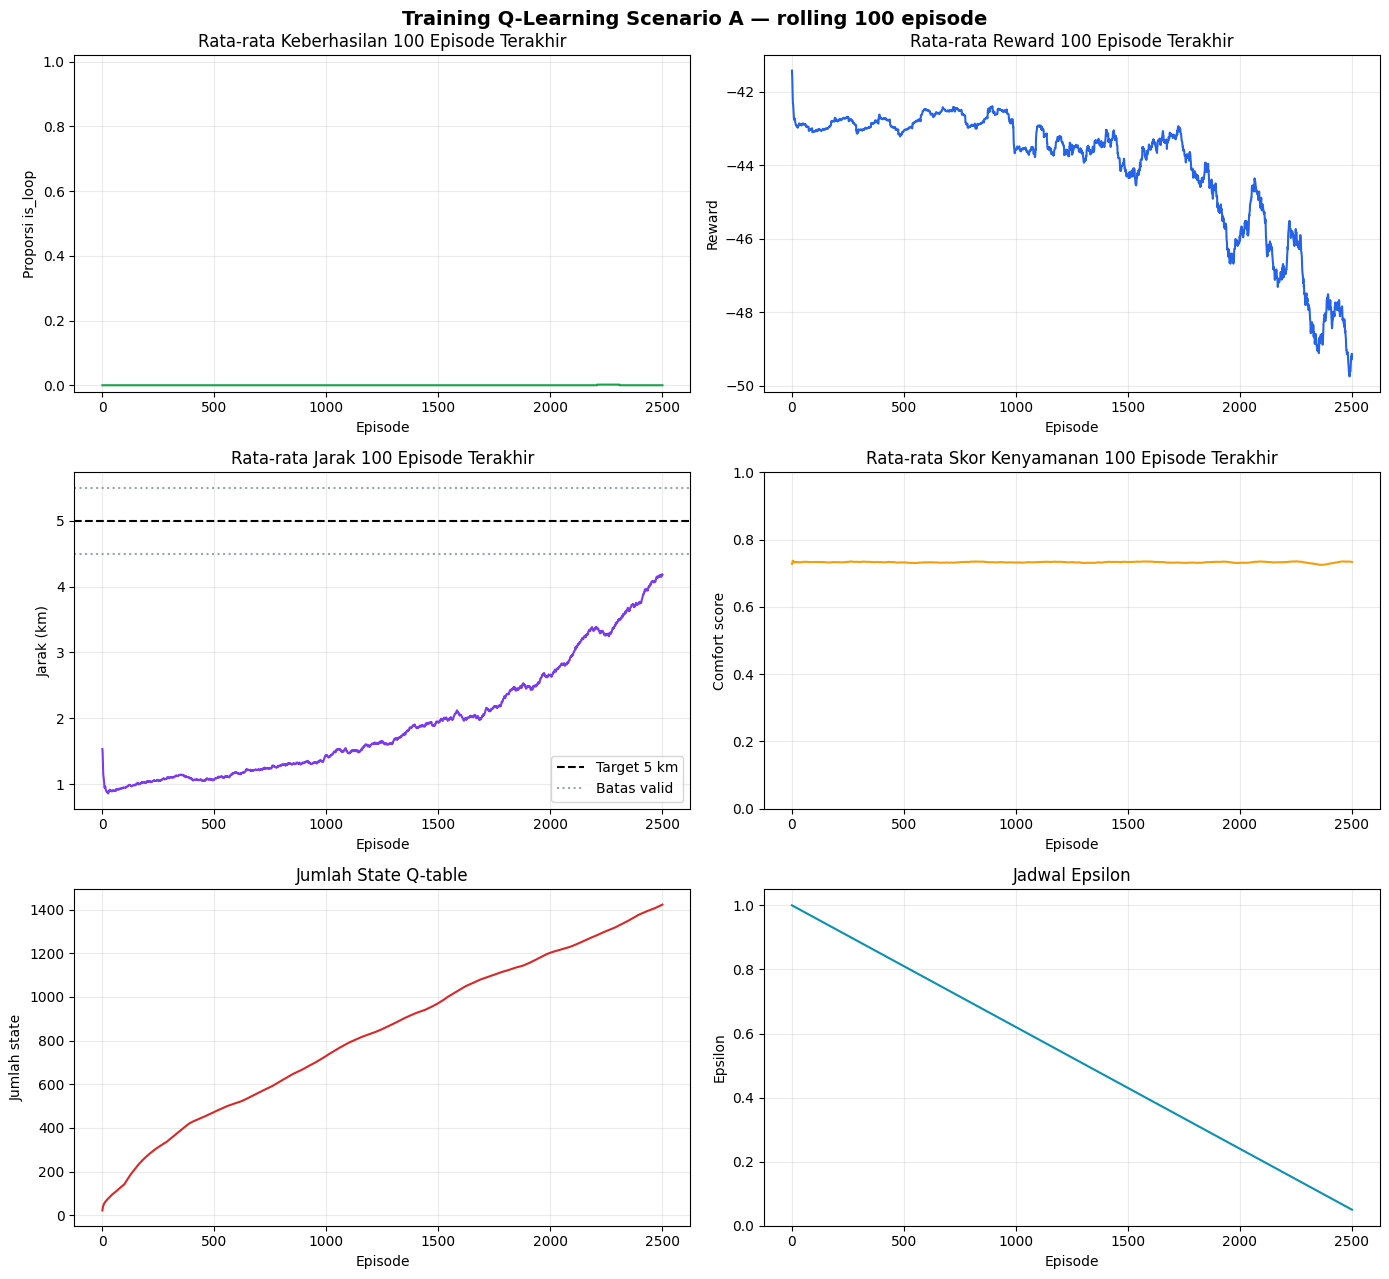

Grafik training tersimpan: hasil_bab_4/training_qlearning_5km/grafik_training_A.png


History: hasil_bab_4/training_qlearning_5km/training_history_A.csv
Evaluasi: hasil_bab_4/training_qlearning_5km/evaluation_metrics_A.csv
Peta: hasil_bab_4/training_qlearning_5km/peta_interaktif_scenario_A.html


In [19]:
history_A, metrics_A, trials_A = run_scenario("A")
present_scenario(history_A, metrics_A, trials_A, "A")


## 3.B Scenario B

State: `(current_node, progress_bin)`. State mengetahui node dan kategori progres jarak.

Setelah training lima seed selesai, sel ini menampilkan metrik evaluasi, grafik rata-rata 100 episode terakhir, grafik jadwal epsilon, dan peta interaktif rute representatif sebelum scenario berikutnya dijalankan.


\nMenjalankan scenario B ...
  seed=0: over_distance, 5.60 km, is_loop=False
  seed=1: over_distance, 5.53 km, is_loop=False
  seed=2: over_distance, 5.51 km, is_loop=False
  seed=3: over_distance, 5.51 km, is_loop=False
  seed=4: over_distance, 5.53 km, is_loop=False


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,training_seconds
0,False,over_distance,5600.438381,5.600438,600.438381,82,-76.610730,0.731289,5,4,0.987805,B,0,7035,0.990749
1,False,over_distance,5526.025495,5.526025,526.025495,65,-35.295943,0.733336,0,0,1.000000,B,1,6928,0.940537
2,False,over_distance,5507.738017,5.507738,507.738017,83,-35.475335,0.735281,0,0,1.000000,B,2,6748,1.028061
3,False,over_distance,5510.833147,5.510833,510.833147,79,-52.022757,0.720042,2,1,1.000000,B,3,6373,0.958623
4,False,over_distance,5527.565795,5.527566,527.565795,83,-44.761790,0.722001,1,1,1.000000,B,4,7001,0.966242


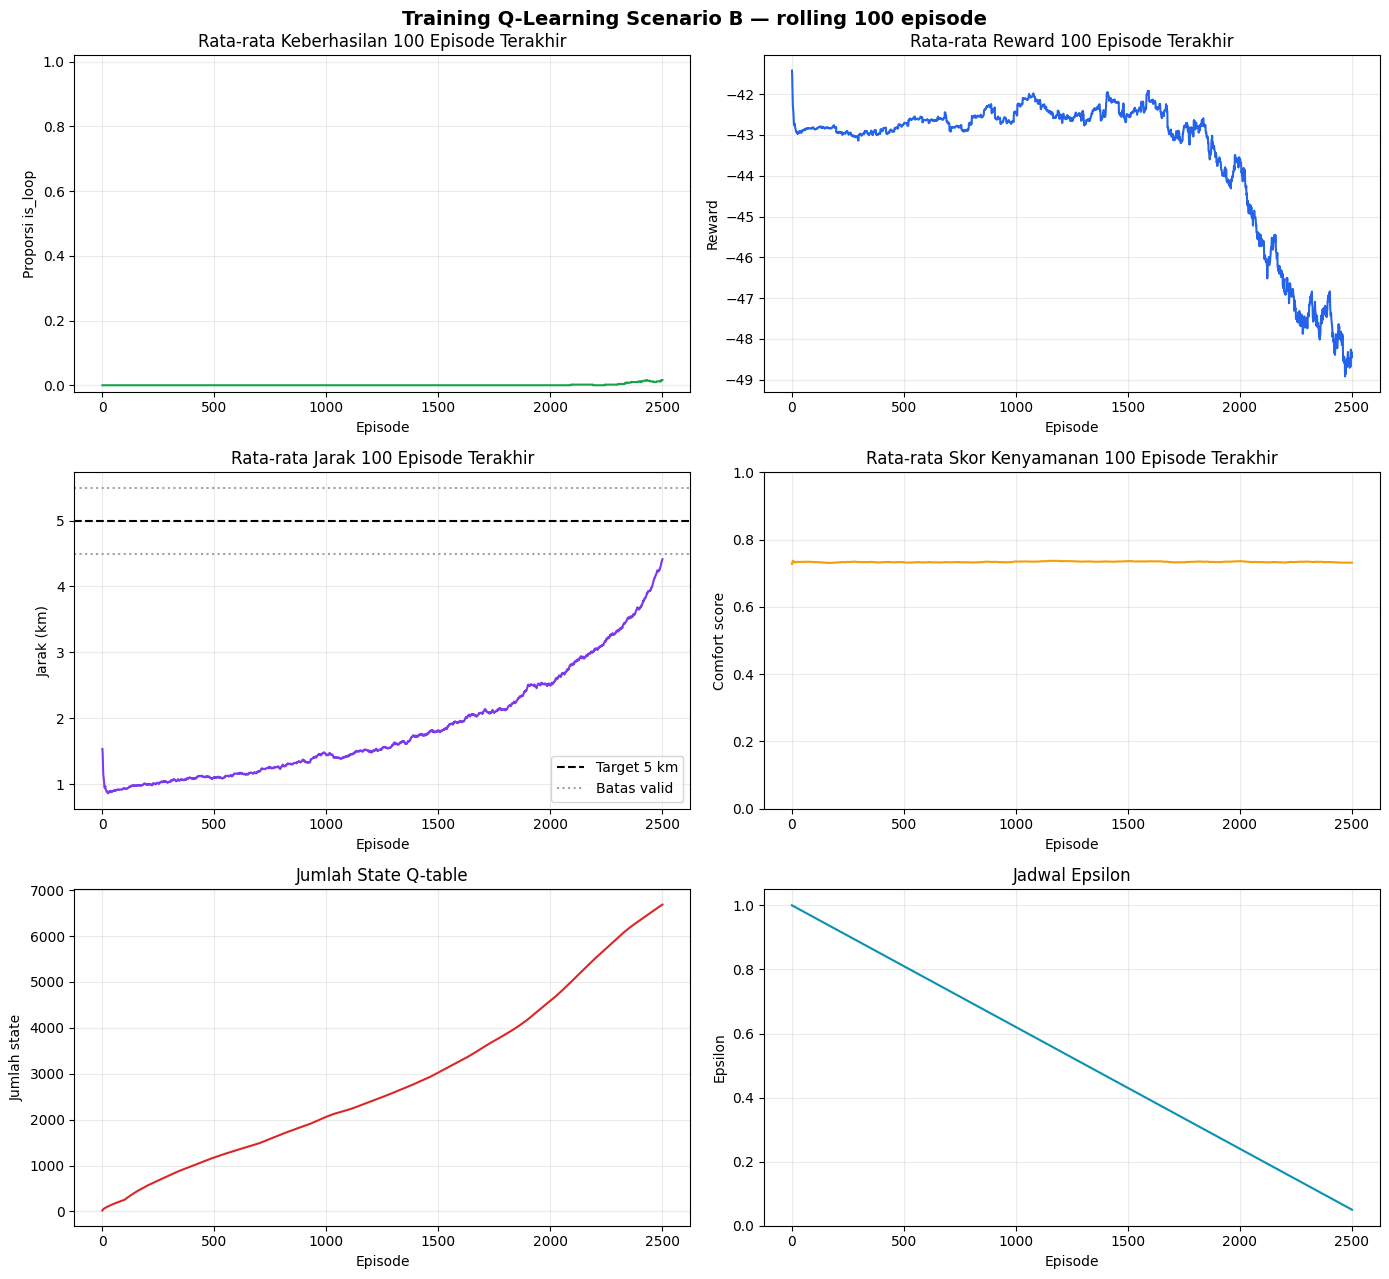

Grafik training tersimpan: hasil_bab_4/training_qlearning_5km/grafik_training_B.png


History: hasil_bab_4/training_qlearning_5km/training_history_B.csv
Evaluasi: hasil_bab_4/training_qlearning_5km/evaluation_metrics_B.csv
Peta: hasil_bab_4/training_qlearning_5km/peta_interaktif_scenario_B.html


In [20]:
history_B, metrics_B, trials_B = run_scenario("B")
present_scenario(history_B, metrics_B, trials_B, "B")


## 3.C Scenario C

State: `(current_node, previous_node, progress_bin)`. State juga mengetahui arah kedatangan agen.

Setelah training lima seed selesai, sel ini menampilkan metrik evaluasi, grafik rata-rata 100 episode terakhir, grafik jadwal epsilon, dan peta interaktif rute representatif sebelum scenario berikutnya dijalankan.


\nMenjalankan scenario C ...
  seed=0: over_distance, 5.57 km, is_loop=False
  seed=1: over_distance, 5.51 km, is_loop=False
  seed=2: no_available_action, 5.25 km, is_loop=False
  seed=3: over_distance, 5.51 km, is_loop=False
  seed=4: over_distance, 5.52 km, is_loop=False


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,training_seconds
0,False,over_distance,5568.330490,5.568330,568.330490,79,-35.714532,0.731043,0,0,1.0,C,0,9542,1.247467
1,False,over_distance,5511.450829,5.511451,511.450829,74,-35.229177,0.731826,0,0,1.0,C,1,9401,0.897830
2,False,no_available_action,5248.847788,5.248848,248.847788,58,-64.795296,0.727699,4,3,1.0,C,2,9913,0.892756
3,False,over_distance,5510.105915,5.510106,510.105915,58,-35.312918,0.763914,0,0,1.0,C,3,9239,0.880855
4,False,over_distance,5515.972746,5.515973,515.972746,75,-43.102275,0.731544,1,1,1.0,C,4,8996,0.924670


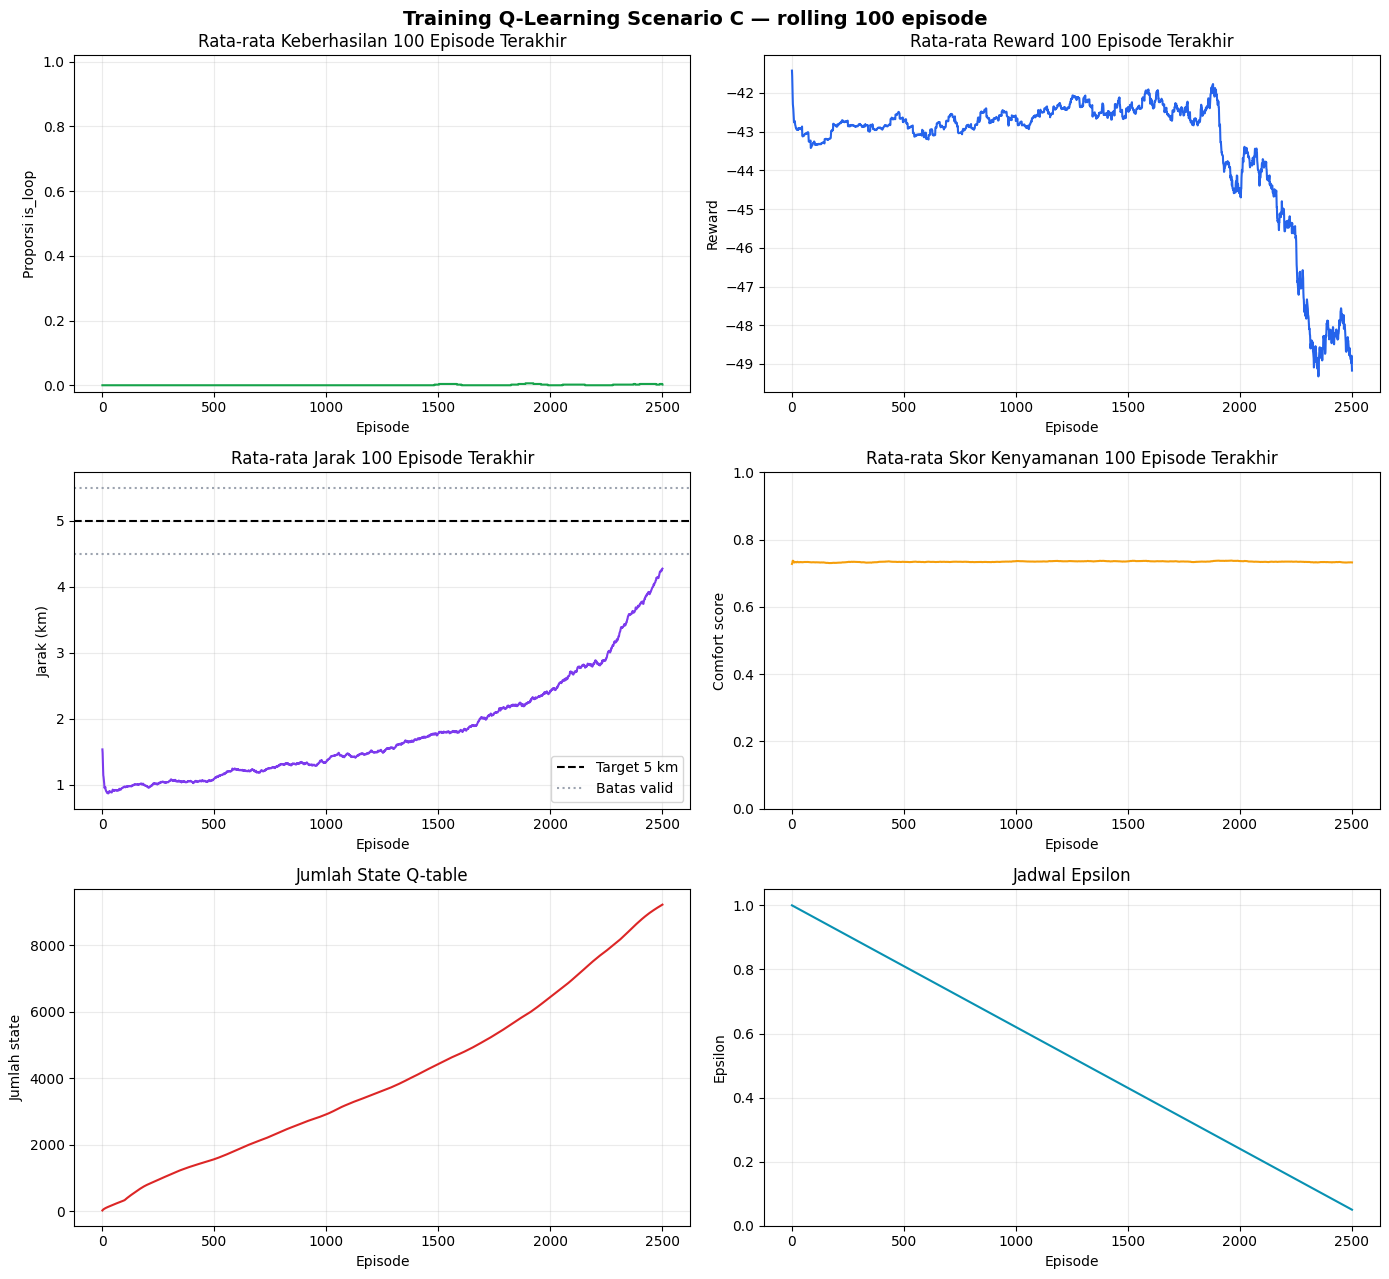

Grafik training tersimpan: hasil_bab_4/training_qlearning_5km/grafik_training_C.png


History: hasil_bab_4/training_qlearning_5km/training_history_C.csv
Evaluasi: hasil_bab_4/training_qlearning_5km/evaluation_metrics_C.csv
Peta: hasil_bab_4/training_qlearning_5km/peta_interaktif_scenario_C.html


In [21]:
history_C, metrics_C, trials_C = run_scenario("C")
present_scenario(history_C, metrics_C, trials_C, "C")


## 3.D Scenario D

State: `(current_node, previous_node, progress_bin, revisit_count_bin)`. State juga mengetahui kategori jumlah revisit yang telah terjadi.

Setelah training lima seed selesai, sel ini menampilkan metrik evaluasi, grafik rata-rata 100 episode terakhir, grafik jadwal epsilon, dan peta interaktif rute representatif sebelum scenario berikutnya dijalankan.


\nMenjalankan scenario D ...
  seed=0: over_distance, 5.56 km, is_loop=False
  seed=1: over_distance, 5.51 km, is_loop=False
  seed=2: no_available_action, 5.03 km, is_loop=False
  seed=3: no_available_action, 3.87 km, is_loop=False
  seed=4: over_distance, 5.55 km, is_loop=False


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,training_seconds
0,False,over_distance,5561.713636,5.561714,561.713636,76,-68.056118,0.733326,4,4,0.986842,D,0,10702,1.001474
1,False,over_distance,5508.856013,5.508856,508.856013,77,-43.843840,0.734510,1,1,1.000000,D,1,10193,0.899544
2,False,no_available_action,5027.336070,5.027336,27.336070,80,-48.239211,0.721390,2,1,0.987500,D,2,10468,0.945864
3,False,no_available_action,3872.905339,3.872905,1127.094661,61,-57.481668,0.731206,3,3,0.983607,D,3,8599,0.851683
4,False,over_distance,5546.681370,5.546681,546.681370,74,-51.402188,0.730213,2,1,1.000000,D,4,9149,0.938195


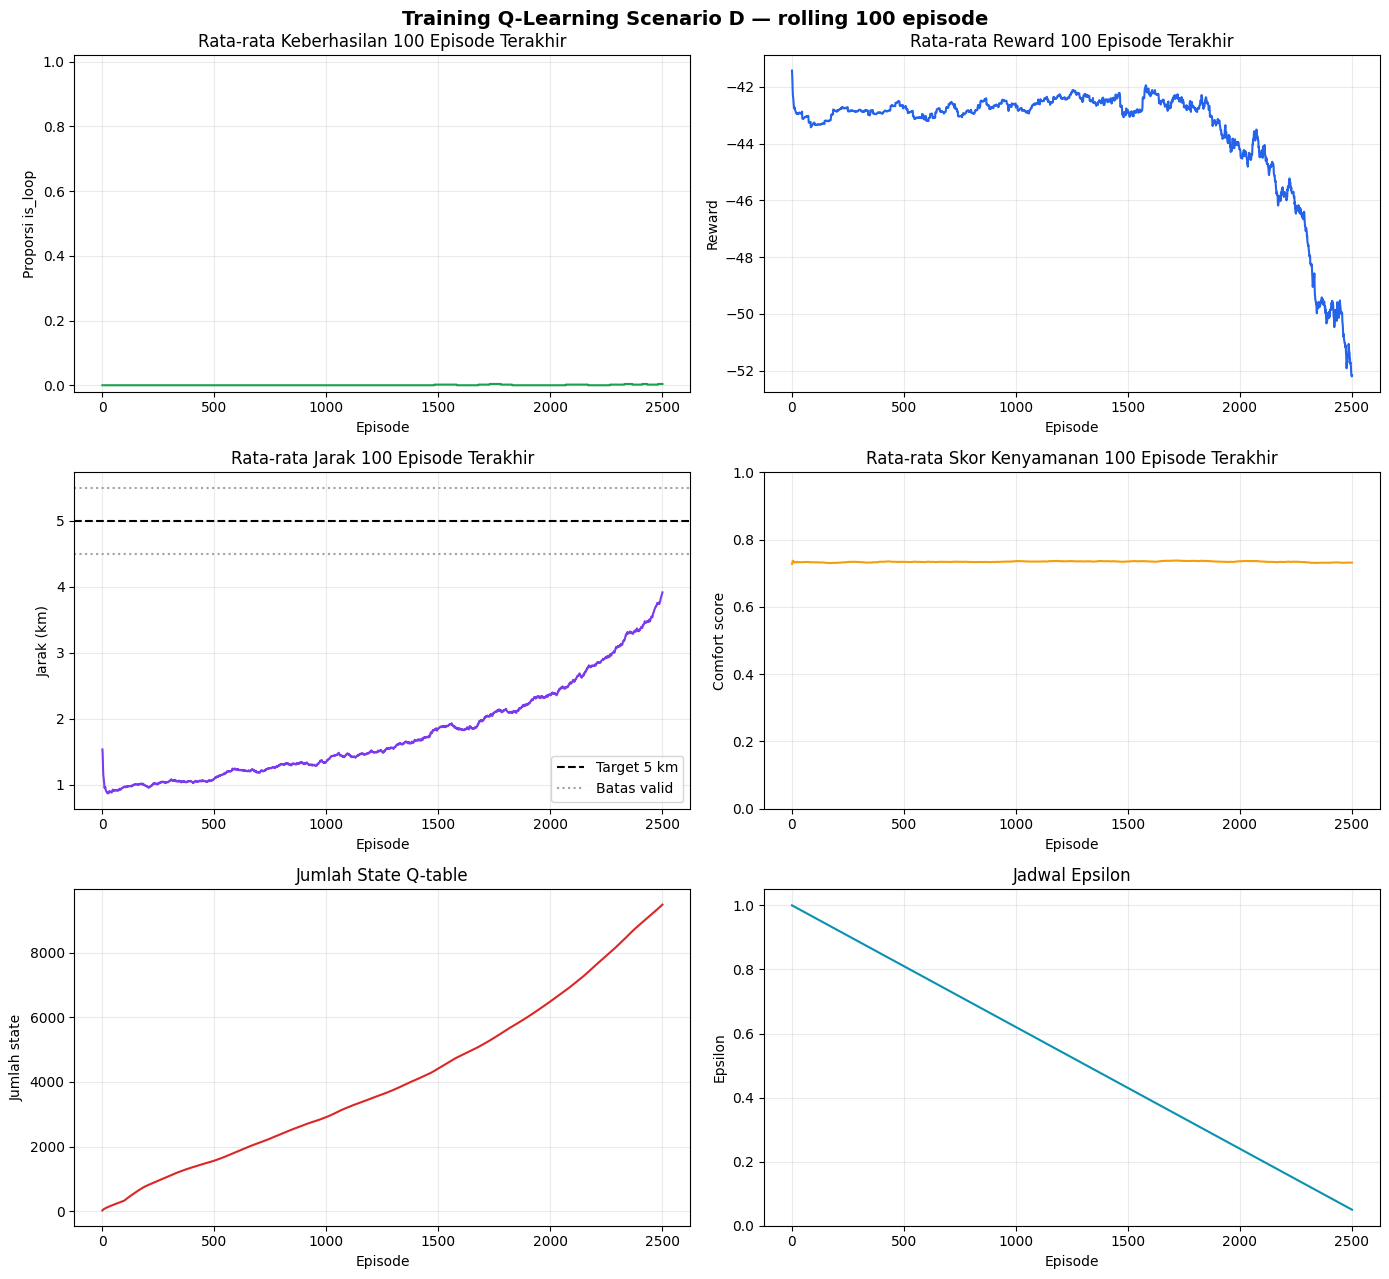

Grafik training tersimpan: hasil_bab_4/training_qlearning_5km/grafik_training_D.png


History: hasil_bab_4/training_qlearning_5km/training_history_D.csv
Evaluasi: hasil_bab_4/training_qlearning_5km/evaluation_metrics_D.csv
Peta: hasil_bab_4/training_qlearning_5km/peta_interaktif_scenario_D.html


In [22]:
history_D, metrics_D, trials_D = run_scenario("D")
present_scenario(history_D, metrics_D, trials_D, "D")


## 4. Perbandingan Akhir Scenario A–D

Tabel berikut menggabungkan hasil evaluasi greedy seluruh seed. Nilai rata-rata dan simpangan baku inilah yang digunakan sebagai dasar pembahasan perbandingan state pada BAB IV.


In [16]:
all_metrics_df = pd.concat(
    [metrics_A, metrics_B, metrics_C, metrics_D],
    ignore_index=True,
).sort_values(["scenario", "seed"]).reset_index(drop=True)

comparison_summary_df = (
    all_metrics_df
    .groupby("scenario", as_index=False)
    .agg(
        is_loop_rate=("is_loop", "mean"),
        distance_km_mean=("distance_km", "mean"),
        distance_km_std=("distance_km", "std"),
        distance_error_m_mean=("absolute_distance_error_m", "mean"),
        mean_comfort_mean=("mean_comfort", "mean"),
        mean_comfort_std=("mean_comfort", "std"),
        revisit_count_mean=("revisit_count", "mean"),
        repeated_nodes_mean=("repeated_intermediate_nodes", "mean"),
        unique_edge_ratio_mean=("unique_edge_ratio", "mean"),
        q_state_count_mean=("q_state_count", "mean"),
        training_seconds_mean=("training_seconds", "mean"),
    )
)

all_metrics_path = RESULT_DIR / "evaluation_metrics_all_scenarios.csv"
summary_path = RESULT_DIR / "comparison_summary_A_to_D.csv"
all_metrics_df.to_csv(all_metrics_path, index=False)
comparison_summary_df.to_csv(summary_path, index=False)

print("=== METRIK EVALUASI SEMUA SEED ===")
display(all_metrics_df)

print("=== RINGKASAN PERBANDINGAN STATE A–D ===")
display(comparison_summary_df.round(3))

print(f"Metrik lengkap: {all_metrics_path}")
print(f"Ringkasan A–D: {summary_path}")


=== METRIK EVALUASI SEMUA SEED ===


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,training_seconds
0,False,no_available_action,3430.234385,3.430234,1569.765615,58,-37.990867,0.709076,0,0,1.000000,A,0,1423,1.020741
1,False,over_distance,5502.918980,5.502919,502.918980,77,-44.347687,0.749372,1,1,1.000000,A,1,1554,1.035484
2,False,no_available_action,4528.759817,4.528760,471.240183,52,-55.252211,0.676649,2,1,0.980769,A,2,1495,1.012464
3,False,over_distance,5523.749131,5.523749,523.749131,76,-59.490261,0.739604,3,2,0.986842,A,3,1426,1.034025
4,False,no_available_action,5216.373050,5.216373,216.373050,83,-74.139857,0.735685,5,5,1.000000,A,4,1344,0.990246
5,False,over_distance,5600.438381,5.600438,600.438381,82,-76.610730,0.731289,5,4,0.987805,B,0,7035,0.981291
6,False,over_distance,5526.025495,5.526025,526.025495,65,-35.295943,0.733336,0,0,1.000000,B,1,6928,1.063521
7,False,over_distance,5507.738017,5.507738,507.738017,83,-35.475335,0.735281,0,0,1.000000,B,2,6748,1.093310
8,False,over_distance,5510.833147,5.510833,510.833147,79,-52.022757,0.720042,2,1,1.000000,B,3,6373,0.939805
9,False,over_distance,5527.565795,5.527566,527.565795,83,-44.761790,0.722001,1,1,1.000000,B,4,7001,1.043971


=== RINGKASAN PERBANDINGAN STATE A–D ===


,scenario,is_loop_rate,distance_km_mean,distance_km_std,distance_error_m_mean,mean_comfort_mean,mean_comfort_std,revisit_count_mean,repeated_nodes_mean,unique_edge_ratio_mean,q_state_count_mean,training_seconds_mean
0,A,0.0,4.840,0.885,656.809,0.722,0.029,2.2,1.8,0.994,1448.4,1.019
1,B,0.0,5.535,0.038,534.520,0.728,0.007,1.6,1.2,0.998,6817.0,1.024
2,C,0.0,5.471,0.127,470.942,0.737,0.015,1.0,0.8,1.000,9418.2,1.002
3,D,0.0,5.103,0.723,554.336,0.730,0.005,2.4,2.0,0.992,9822.2,0.952


Metrik lengkap: hasil_bab_4/training_qlearning_5km/evaluation_metrics_all_scenarios.csv
Ringkasan A–D: hasil_bab_4/training_qlearning_5km/comparison_summary_A_to_D.csv
